# Indonesia customer hotspot baseline

Calculate confusion matrices for **2019, 2023, 2025, 2026**, and the pooled total from `hotspot_master_2019_2023_2025_2026.xlsx`.

**Prediction definition:** every supplied hotspot is an alert (`1`). The workbook has no alert/no-alert predictions or filter features. These matrices evaluate the fire confirmation rate of the supplied hotspot subset; they cannot measure missed fires outside that subset or reproduce the separate Hotspot Analytics matrix. TN and FN are structurally zero, not evidence that the system never misses fires. Recall and specificity are therefore not reported as system performance.

**Labels:** `Verified Fire` and, by an explicit configurable assumption, `Fire inside Sitrep` map to fire; `Verified No fire` maps to no fire. `Unverified` and missing statuses are excluded. A second analysis uses only explicitly verified statuses.

**Rows:** combine all sheets, derive year from `Tgl_Hotspot`, and remove exact duplicates across the seven source columns. Keep provenance and export the excluded duplicate rows. Distinct hotspot records are not merged into fire events. Two observations have both unverified and verified versions; the unverified versions are excluded from scoring, with all versions exported for audit. `Sheet1` overlaps the 2026 sheet and is not a separate year.

Run all cells from the repository root or `notebooks/`. Dependencies: pandas, openpyxl, numpy, matplotlib, IPython (plus Jupyter to open the notebook). Outputs are saved under `notebooks/outputs/customer_hotspot_baseline/`.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/customer/hotspot_master_2019_2023_2025_2026.xlsx').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Run from the repository root or a subdirectory.')
WORKBOOK = ROOT / 'data/customer/hotspot_master_2019_2023_2025_2026.xlsx'
OUT = ROOT / 'notebooks/outputs/customer_hotspot_baseline'
OUT.mkdir(parents=True, exist_ok=True)
YEARS = [2019, 2023, 2025, 2026]
INCLUDE_SITREP_AS_FIRE = True
SOURCE_COLUMNS = ['Longitude', 'Latitude', 'Tgl_Hotspot', 'Sumber', 'Satellite', 'Status', 'Region']
print('Workbook:', WORKBOOK.name)


Workbook: hotspot_master_2019_2023_2025_2026.xlsx


In [2]:
sheets = pd.read_excel(WORKBOOK, sheet_name=None, engine='openpyxl')
parts, sheet_audit = [], []
for name, frame in sheets.items():
    if list(frame.columns) != SOURCE_COLUMNS:
        raise ValueError(f'Unexpected columns in {name}: {list(frame.columns)}')
    frame = frame.copy()
    frame['source_sheet'] = str(name)
    frame['excel_row'] = np.arange(len(frame)) + 2
    blank = frame[SOURCE_COLUMNS].isna().all(axis=1)
    sheet_audit.append({'sheet': name, 'rows_read': len(frame), 'blank_rows': int(blank.sum()),
                        'nonblank_rows': int((~blank).sum())})
    parts.append(frame.loc[~blank])
raw = pd.concat(parts, ignore_index=True)
duplicate_mask = raw.duplicated(SOURCE_COLUMNS, keep='first')
duplicates = raw.loc[duplicate_mask].copy()
data = raw.loc[~duplicate_mask].copy()
data['date'] = pd.to_datetime(data['Tgl_Hotspot'], errors='coerce')
if data['date'].isna().any():
    raise ValueError('Missing or invalid dates; resolve before assigning years.')
data['year'] = data['date'].dt.year
if set(data['year']) != set(YEARS):
    raise ValueError(f'Unexpected or missing years: {sorted(data.year.unique())}')
data['status_normalized'] = data['Status'].astype('string').str.strip().str.casefold()
known = {'verified fire', 'verified no fire', 'fire inside sitrep', 'unverified'}
unknown = set(data['status_normalized'].dropna()) - known
if unknown:
    raise ValueError(f'Unmapped statuses: {unknown}')
# Detect contradictory checks for otherwise identical observations.
identity = [c for c in SOURCE_COLUMNS if c != 'Status']
conflicts = data.groupby(identity, dropna=False)['status_normalized'].nunique(dropna=False)
status_versions = data.loc[data.groupby(identity, dropna=False)['status_normalized'].transform('nunique') > 1]
status_versions.to_csv(OUT / 'observations_with_status_versions.csv', index=False)
print(f'{len(status_versions)} rows have multiple status versions; unverified versions are excluded from scoring.')
display(pd.DataFrame(sheet_audit))
print(f'{len(raw):,} nonblank rows; {len(duplicates):,} exact duplicates removed; {len(data):,} unique rows.')
status_counts = pd.crosstab(data['year'], data['status_normalized'].fillna('(missing)')).reindex(YEARS, fill_value=0)
display(status_counts)
duplicates.to_csv(OUT / 'excluded_exact_duplicates.csv', index=False)
status_counts.to_csv(OUT / 'status_counts_by_year.csv')


4 rows have multiple status versions; unverified versions are excluded from scoring.


,sheet,rows_read,blank_rows,nonblank_rows
0,Sheet1,326,0,326
1,2019,11426,0,11426
2,2023,30029,0,30029
3,2025,1309,0,1309
4,2026,1179,0,1179


44,269 nonblank rows; 324 exact duplicates removed; 43,945 unique rows.


status_normalized,fire inside sitrep,unverified,verified fire,verified no fire
year,,,,
2019,2583,0,7103,1740
2023,23776,0,484,5769
2025,132,0,39,1138
2026,151,33,41,956


## Calculate the baseline

Matrix orientation is **rows = checked status [no fire, fire]**, **columns = prediction [no alert, alert]**: `[[TN, FP], [FN, TP]]`. Counts and percentages use evaluated rows only. Accuracy and precision coincide for this all-alert baseline. False discovery rate is FP / (TP + FP), the fraction of alerts checked as no fire; it is not the population false-positive rate. The pooled total sums counts before calculating metrics.


In [3]:
def evaluate(frame, include_sitrep):
    label_map = {'verified no fire': 0, 'verified fire': 1}
    if include_sitrep:
        label_map['fire inside sitrep'] = 1
    scored = frame.copy()
    scored['actual_fire'] = scored['status_normalized'].map(label_map)
    scored['predicted_alert'] = 1  # Explicit all-hotspots-alert baseline, not recovered analytics output.
    scored['evaluated'] = scored['actual_fire'].notna()
    labeled = scored.loc[scored['evaluated']]
    if (labeled.groupby(identity, dropna=False)['actual_fire'].nunique() > 1).any():
        raise ValueError('Contradictory fire/no-fire labels require adjudication.')
    records, matrices = [], {}
    for year in [*YEARS, 'Total']:
        group = scored if year == 'Total' else scored.loc[scored['year'] == year]
        valid = group.loc[group['evaluated']]
        matrix = np.zeros((2, 2), dtype=int)
        np.add.at(matrix, (valid['actual_fire'].to_numpy(dtype=int),
                           valid['predicted_alert'].to_numpy(dtype=int)), 1)
        tn, fp, fn, tp = matrix.ravel()
        n = int(matrix.sum())
        matrices[str(year)] = matrix
        records.append(dict(year=str(year), unique_rows=len(group), evaluated=n,
                            excluded=len(group)-n, TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp),
                            accuracy=(tp+tn)/n if n else np.nan,
                            precision=tp/(tp+fp) if tp+fp else np.nan,
                            false_discovery_rate=fp/(tp+fp) if tp+fp else np.nan))
    summary = pd.DataFrame(records).set_index('year')
    assert np.array_equal(matrices['Total'], sum(matrices[str(y)] for y in YEARS))
    assert (summary['evaluated'] == summary[['TN','FP','FN','TP']].sum(axis=1)).all()
    assert (summary['unique_rows'] == summary['evaluated'] + summary['excluded']).all()
    return summary, matrices, scored

summary, matrices, scored = evaluate(data, INCLUDE_SITREP_AS_FIRE)
strict_summary, strict_matrices, _ = evaluate(data, False)
display(summary.round(4))
print('Sensitivity analysis: explicitly verified statuses only')
display(strict_summary.round(4))
summary.to_csv(OUT / 'baseline_metrics.csv')
strict_summary.to_csv(OUT / 'strict_verified_metrics.csv')
scored.to_csv(OUT / 'baseline_rows.csv', index=False)
scored.loc[~scored['evaluated']].to_csv(OUT / 'excluded_unlabeled_rows.csv', index=False)


,unique_rows,evaluated,excluded,TN,FP,FN,TP,accuracy,precision,false_discovery_rate
year,,,,,,,,,,
2019,11426,11426,0,0,1740,0,9686,0.8477,0.8477,0.1523
2023,30029,30029,0,0,5769,0,24260,0.8079,0.8079,0.1921
2025,1309,1309,0,0,1138,0,171,0.1306,0.1306,0.8694
2026,1181,1148,33,0,956,0,192,0.1672,0.1672,0.8328
Total,43945,43912,33,0,9603,0,34309,0.7813,0.7813,0.2187


Sensitivity analysis: explicitly verified statuses only


,unique_rows,evaluated,excluded,TN,FP,FN,TP,accuracy,precision,false_discovery_rate
year,,,,,,,,,,
2019,11426,8843,2583,0,1740,0,7103,0.8032,0.8032,0.1968
2023,30029,6253,23776,0,5769,0,484,0.0774,0.0774,0.9226
2025,1309,1177,132,0,1138,0,39,0.0331,0.0331,0.9669
2026,1181,997,184,0,956,0,41,0.0411,0.0411,0.9589
Total,43945,17270,26675,0,9603,0,7667,0.4439,0.4439,0.5561


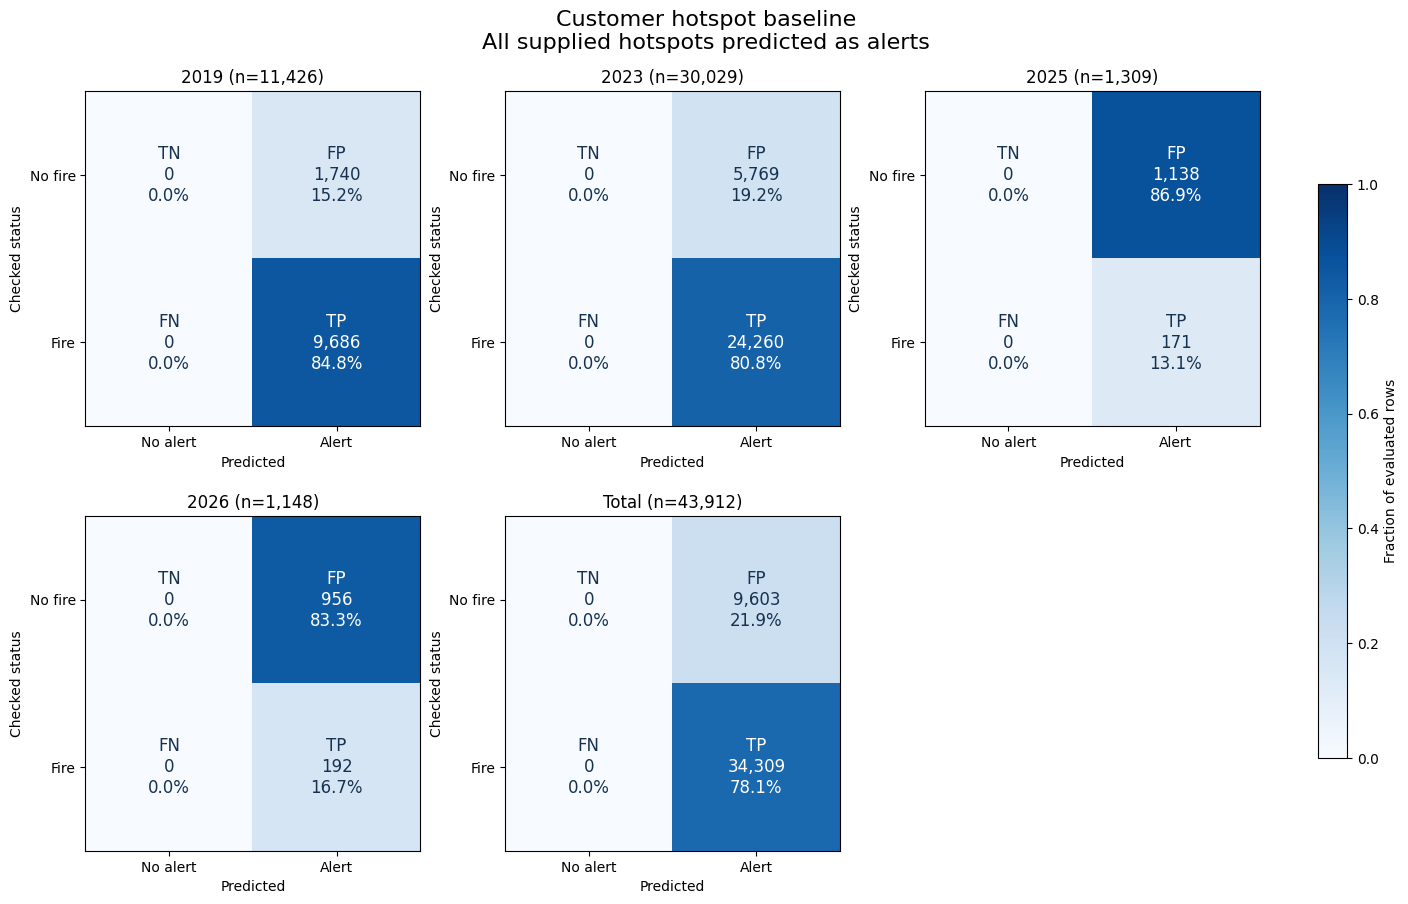

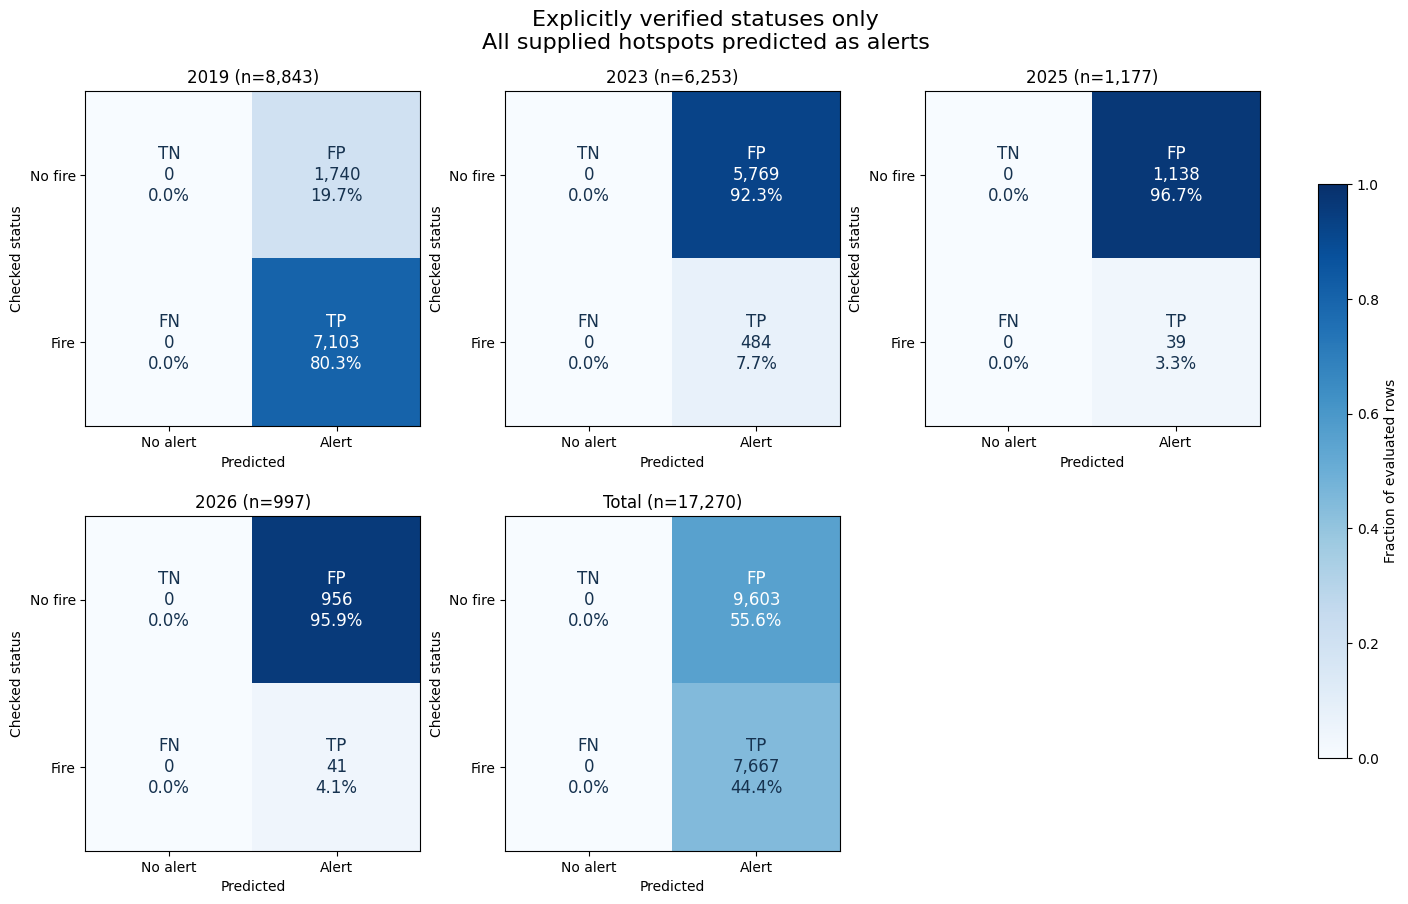

In [4]:
def plot_matrices(matrices, title, filename):
    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
    names = np.array([['TN', 'FP'], ['FN', 'TP']])
    for ax, (year, matrix) in zip(axes.flat, matrices.items()):
        n = matrix.sum()
        fractions = matrix / n if n else np.zeros((2, 2))
        im = ax.imshow(fractions, cmap='Blues', vmin=0, vmax=1)
        for row in range(2):
            for col in range(2):
                pct = f'{fractions[row, col]:.1%}' if n else 'N/A'
                ax.text(col, row, f'{names[row,col]}\n{matrix[row,col]:,}\n{pct}',
                        ha='center', va='center', fontsize=12,
                        color='white' if fractions[row,col] > 0.5 else '#16324f')
        ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['No alert','Alert'],
               yticklabels=['No fire','Fire'], xlabel='Predicted', ylabel='Checked status',
               title=f'{year} (n={n:,})')
    axes.flat[-1].axis('off')
    fig.colorbar(im, ax=list(axes.flat)[:-1], shrink=0.7, label='Fraction of evaluated rows')
    fig.suptitle(title + '\nAll supplied hotspots predicted as alerts', fontsize=16)
    fig.savefig(OUT / filename, dpi=180, bbox_inches='tight')
    plt.show()

plot_matrices(matrices, 'Customer hotspot baseline', 'confusion_matrices.png')
plot_matrices(strict_matrices, 'Explicitly verified statuses only', 'strict_confusion_matrices.png')


## Compare with the supplied image and preserve provenance

The supplied `confusion matrix.jpeg` reports TN=2,670, FP=7,180, FN=2,545, TP=31,841 (44,236 evaluated rows). These counts are transcribed for comparison, not used as predictions. Reproducing that matrix requires the original row-level alert decisions, labeling policy, and evaluated dataset. Do not infer no-alert decisions from the verification status itself; that would leak the answer into the prediction.

For later model comparisons, use the same evaluated rows and label policy, join predictions to their observations, and include independently sampled non-alert observations before making claims about missed-fire performance. These customer-selected hotspot rows do not represent all Indonesian locations or all fire events. Date ranges below show actual coverage, including partial 2026 coverage.


In [5]:
reference = pd.Series({'TN':2670, 'FP':7180, 'FN':2545, 'TP':31841}, name='supplied_image')
comparison = pd.concat([reference, summary.loc['Total', ['TN','FP','FN','TP']].rename('this_baseline')], axis=1)
display(comparison)
coverage = data.groupby('year')['date'].agg(['min','max','count'])
display(coverage)
comparison.to_csv(OUT / 'supplied_image_comparison.csv')
coverage.to_csv(OUT / 'date_coverage.csv')
metadata = {
    'workbook': str(WORKBOOK.relative_to(ROOT)),
    'workbook_sha256': hashlib.sha256(WORKBOOK.read_bytes()).hexdigest(),
    'prediction_policy': 'Every supplied hotspot is an alert; no original analytics predictions available.',
    'include_sitrep_as_fire': INCLUDE_SITREP_AS_FIRE,
    'deduplication_columns': SOURCE_COLUMNS,
    'raw_nonblank_rows': len(raw), 'exact_duplicates_removed': len(duplicates),
    'unique_rows': len(data), 'years': YEARS,
    'python': platform.python_version(), 'pandas': pd.__version__,
    'numpy': np.__version__, 'matplotlib': matplotlib.__version__,
}
(OUT / 'provenance.json').write_text(json.dumps(metadata, indent=2) + '\n')
print('Saved baseline tables, row audit, figures, and provenance to:', OUT)


,supplied_image,this_baseline
TN,2670,0.0
FP,7180,9603.0
FN,2545,0.0
TP,31841,34309.0


,min,max,count
year,,,
2019,2019-01-04 10:00:00,2019-12-30 14:00:00,11426
2023,2023-01-06 13:00:00,2023-12-31 13:00:00,30029
2025,2025-01-01 01:00:00,2025-12-27 01:00:00,1309
2026,2026-01-02 00:00:00,2026-08-07 03:00:00,1181


Saved baseline tables, row audit, figures, and provenance to: /Volumes/Portable Drive/sensenet/hotspot_detection_new/notebooks/outputs/customer_hotspot_baseline
